In [1]:
!pip install nibabel scikit-image matplotlib -q

In [3]:
import os
import glob
import pandas as pd
import numpy as np
import nibabel as nib
from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                             precision_score, roc_auc_score,
                             balanced_accuracy_score, confusion_matrix)
import matplotlib.pyplot as plt
from scipy import ndimage
import warnings
warnings.filterwarnings('ignore')

# ===== 1. ЗАГРУЗКА ДАННЫХ =====

# Укажите путь к taowu у себя на машине
# Например: '/Users/yourname/projects/taowu' или 'C:\\Users\\...\\taowu'
TAOWU_PATH = '../../taowu'

# Найдём все T1w сканы
nii_files = sorted(glob.glob(os.path.join(TAOWU_PATH, 'sub-*/anat/*_T1w.nii.gz')))
print(f"Найдено T1w сканов: {len(nii_files)}")

# Разделим на Control и Patient
subjects = []
labels = []  # 0 = Control, 1 = Patient
groups = []  # для group k-fold

for f in nii_files:
    basename = os.path.basename(f)
    if 'control' in basename:
        label = 0
        subj_id = basename.split('_')[0].replace('sub-', '')
    else:
        label = 1
        subj_id = basename.split('_')[0].replace('sub-', '')

    subjects.append(f)
    labels.append(label)
    groups.append(subj_id)

labels = np.array(labels)
print(f"Control (0): {sum(labels==0)}, Patient (1): {sum(labels==1)}")

# ===== 2. ПРЕПРОЦЕССИНГ =====

def preprocess_nifti(filepath, target_shape=(128, 128, 128)):
    """
    Загружает .nii.gz, ресемплит, нормализует
    """
    img = nib.load(filepath)
    data = img.get_fdata()

    # Ресемплинг к target_shape
    zoom_factors = [t/s for t, s in zip(target_shape, data.shape)]
    data_resampled = ndimage.zoom(data, zoom_factors, order=1)

    # Z-score нормализация
    data_norm = (data_resampled - np.mean(data_resampled)) / np.std(data_resampled)

    return data_norm

# ===== 3. ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ (2D-срезы для MobileNetV2) =====

def extract_slices(volume, n_slices=16):
    """
    Извлекает n_slices аксиальных срезов из 3D-объёма
    Возвращает массив (n_slices, H, W)
    """
    z_dim = volume.shape[2]
    indices = np.linspace(z_dim//4, 3*z_dim//4, n_slices).astype(int)
    slices = volume[:, :, indices]
    # Переставляем оси: (H, W, n_slices) -> (n_slices, H, W)
    slices = np.transpose(slices, (2, 0, 1))
    return slices

# ===== 4. ПОЛНЫЙ PIPELINE =====

print("\nЗагрузка и препроцессинг всех сканов...")
all_features = []
all_labels = []
all_groups = []

for i, (subj_file, label, group) in enumerate(zip(subjects, labels, groups)):
    print(f"  [{i+1}/{len(subjects)}] {group}...", end='\r')

    # Загрузка и препроцессинг
    volume = preprocess_nifti(subj_file, target_shape=(128, 128, 128))

    # Извлечение срезов
    slices = extract_slices(volume, n_slices=16)

    # Усреднение срезов в один вектор признаков (упрощённо)
    # ИЛИ: подаём каждый срез отдельно
    feature_vector = np.mean(slices, axis=0).flatten()  # усреднение по срезам

    all_features.append(feature_vector)
    all_labels.append(label)
    all_groups.append(group)

print(f"\nГотово! Признаки: {len(all_features)} образцов, размер вектора: {all_features[0].shape}")

X = np.array(all_features)
y = np.array(all_labels)
groups = np.array(all_groups)

# ===== 5. GROUP K-FOLD CV =====

print("\n" + "="*50)
print("GROUP K-FOLD CROSS-VALIDATION")
print("="*50)

# Параметры SVM (подберём grid search'ом)
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'kernel': ['rbf', 'linear']
}

# Или фиксированные параметры для начала
best_params = {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}

gkf = GroupKFold(n_splits=5)

metrics = {
    'accuracy': [], 'f1': [], 'sensitivity': [],
    'specificity': [], 'balanced_acc': [], 'auc': []
}

fold = 1
for train_idx, test_idx in gkf.split(X, y, groups=groups):
    print(f"\nFold {fold}:")
    print(f"  Train: {len(train_idx)} samples")
    print(f"  Test:  {len(test_idx)} samples -> {np.array(groups)[test_idx]}")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Нормализация
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # SVM
    clf = SVC(**best_params, probability=True, random_state=42)
    clf.fit(X_train_scaled, y_train)

    # Предсказания
    y_pred = clf.predict(X_test_scaled)
    y_prob = clf.predict_proba(X_test_scaled)[:, 1]

    # Метрики
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    sens = recall_score(y_test, y_pred)  # sensitivity = recall для positive class
    spec = recall_score(y_test, y_pred, pos_label=0)  # specificity
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob) if len(np.unique(y_test)) > 1 else 0.5

    print(f"  Accuracy: {acc:.3f}, F1: {f1:.3f}, AUC: {auc:.3f}")

    metrics['accuracy'].append(acc)
    metrics['f1'].append(f1)
    metrics['sensitivity'].append(sens)
    metrics['specificity'].append(spec)
    metrics['balanced_acc'].append(bal_acc)
    metrics['auc'].append(auc)

    fold += 1

# ===== 6. ИТОГОВЫЕ РЕЗУЛЬТАТЫ =====

print("\n" + "="*50)
print("FINAL RESULTS (Mean ± Std)")
print("="*50)

for metric_name, values in metrics.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    print(f"{metric_name:15s}: {mean_val:.3f} ± {std_val:.3f}")

print(f"\n{'='*50}")
print(f"OLD MRI accuracy: 0.998")
print(f"NEW MRI accuracy: {np.mean(metrics['accuracy']):.3f}")
print(f"{'='*50}")

Найдено T1w сканов: 40
Control (0): 20, Patient (1): 20

Загрузка и препроцессинг всех сканов...
  [40/40] patient032096...
Готово! Признаки: 40 образцов, размер вектора: (16384,)

GROUP K-FOLD CROSS-VALIDATION

Fold 1:
  Train: 32 samples
  Test:  8 samples -> ['control032061' 'control032066' 'control032071' 'control032076'
 'patient032081' 'patient032086' 'patient032091' 'patient032096']
  Accuracy: 0.875, F1: 0.889, AUC: 0.062

Fold 2:
  Train: 32 samples
  Test:  8 samples -> ['control032060' 'control032065' 'control032070' 'control032075'
 'patient032080' 'patient032085' 'patient032090' 'patient032095']
  Accuracy: 0.500, F1: 0.600, AUC: 0.312

Fold 3:
  Train: 32 samples
  Test:  8 samples -> ['control032059' 'control032064' 'control032069' 'control032074'
 'patient032079' 'patient032084' 'patient032089' 'patient032094']
  Accuracy: 0.625, F1: 0.667, AUC: 0.250

Fold 4:
  Train: 32 samples
  Test:  8 samples -> ['control032058' 'control032063' 'control032068' 'control032073'
 'pa

Найдено T1w сканов: 40
Control (0): 20, Patient (1): 20

Загрузка и препроцессинг всех сканов...
  [40/40] patient032096...
Готово! Признаки: 40 образцов, размер вектора: (71,)

GROUP K-FOLD CROSS-VALIDATION WITH GRID SEARCH

Fold 1:
  Train: 32 samples
  Test:  8 samples
  Test subjects: ['control032061' 'control032066' 'control032071' 'control032076'
 'patient032081' 'patient032086' 'patient032091' 'patient032096']
  Test labels:   [0 0 0 0 1 1 1 1]
  Best params: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
  y_test: [0 0 0 0 1 1 1 1]
  y_pred: [0 1 1 1 1 1 1 0]
  y_prob: [0.488 0.5   0.51  0.5   0.547 0.524 0.58  0.437]
  Accuracy: 0.500, F1: 0.600, AUC: 0.750
  Sensitivity: 0.750, Specificity: 0.250

Fold 2:
  Train: 32 samples
  Test:  8 samples
  Test subjects: ['control032060' 'control032065' 'control032070' 'control032075'
 'patient032080' 'patient032085' 'patient032090' 'patient032095']
  Test labels:   [0 0 0 0 1 1 1 1]
  Best params: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}

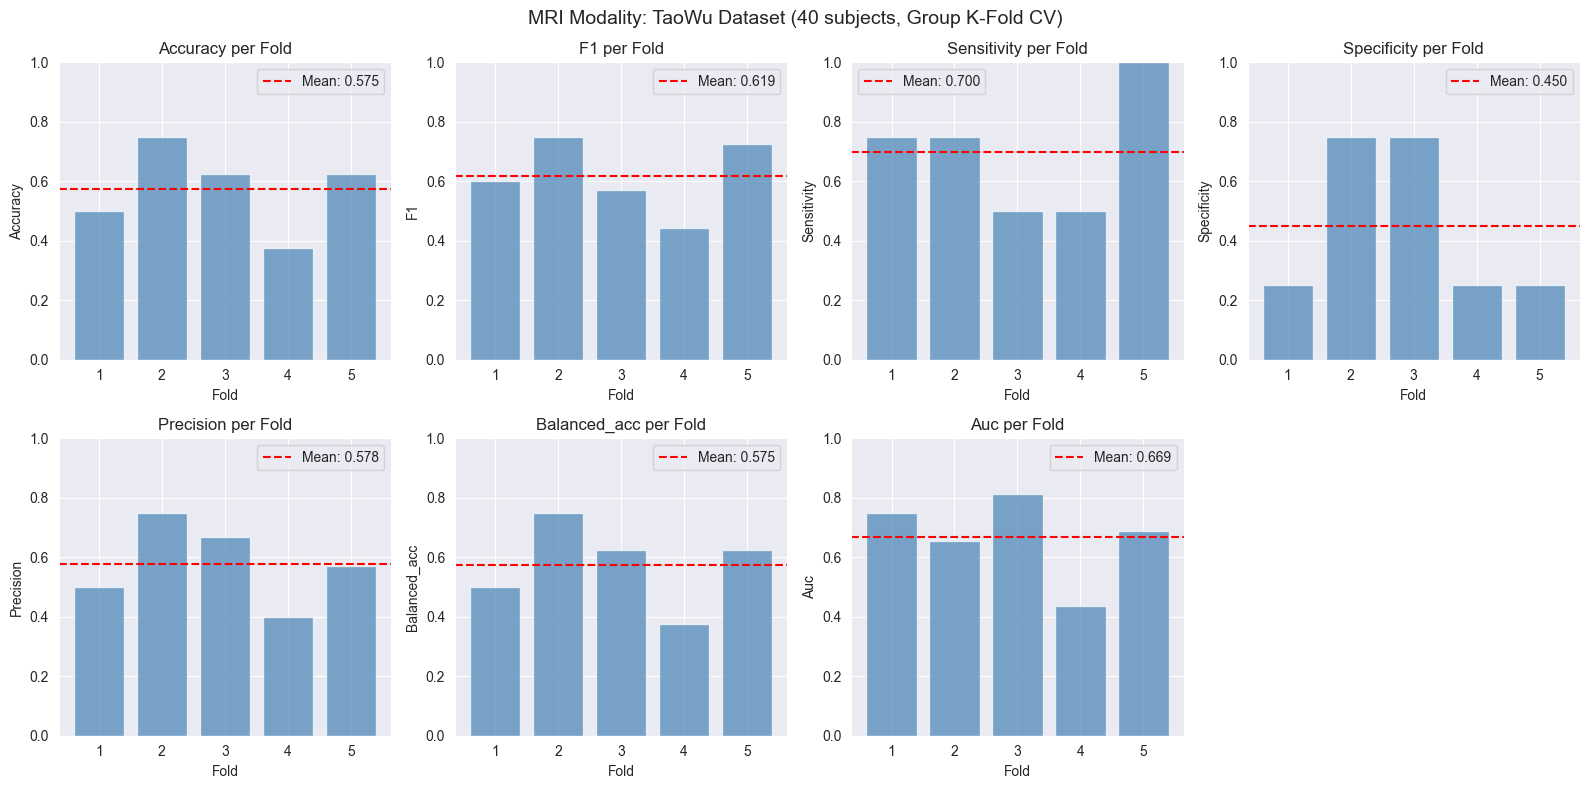


✅ Результаты сохранены в mri_taowu_results.png


In [8]:
import os
import glob
import pandas as pd
import numpy as np
import nibabel as nib
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                             precision_score, roc_auc_score,
                             balanced_accuracy_score, confusion_matrix,
                             classification_report)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from scipy import ndimage
import warnings
warnings.filterwarnings('ignore')

TAOWU_PATH = '../../taowu'

# ===== 1. ЗАГРУЗКА ДАННЫХ =====
nii_files = sorted(glob.glob(os.path.join(TAOWU_PATH, 'sub-*/anat/*_T1w.nii.gz')))
print(f"Найдено T1w сканов: {len(nii_files)}")

subjects = []
labels = []
groups = []

for f in nii_files:
    basename = os.path.basename(f)
    if 'control' in basename:
        label = 0
        subj_id = basename.split('_')[0].replace('sub-', '')
    else:
        label = 1
        subj_id = basename.split('_')[0].replace('sub-', '')

    subjects.append(f)
    labels.append(label)
    groups.append(subj_id)

labels = np.array(labels)
print(f"Control (0): {sum(labels==0)}, Patient (1): {sum(labels==1)}")

# ===== 2. УЛУЧШЕННЫЙ ПРЕПРОЦЕССИНГ =====

def preprocess_nifti(filepath, target_shape=(128, 128, 128)):
    img = nib.load(filepath)
    data = img.get_fdata()
    zoom_factors = [t/s for t, s in zip(target_shape, data.shape)]
    data_resampled = ndimage.zoom(data, zoom_factors, order=1)
    data_norm = (data_resampled - np.mean(data_resampled)) / (np.std(data_resampled) + 1e-8)
    return data_norm

# ===== 3. УЛУЧШЕННОЕ ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ =====

def extract_features(volume, n_slices=32):
    features = []
    features.extend([
        np.mean(volume), np.std(volume), np.median(volume),
        np.percentile(volume, 25), np.percentile(volume, 75),
        np.max(volume), np.min(volume),
    ])
    hist, _ = np.histogram(volume.flatten(), bins=16, range=(-3, 3))
    features.extend(hist)
    z_dim = volume.shape[2]
    slice_indices = np.linspace(z_dim//4, 3*z_dim//4, n_slices).astype(int)
    for idx in slice_indices:
        slice_data = volume[:, :, idx]
        features.extend([np.mean(slice_data), np.std(slice_data), np.median(slice_data)])
    return np.array(features)

# ===== 4. ПОЛНЫЙ PIPELINE =====

print("\nЗагрузка и препроцессинг всех сканов...")
all_features = []
all_labels = []
all_groups = []

for i, (subj_file, label, group) in enumerate(zip(subjects, labels, groups)):
    print(f"  [{i+1}/{len(subjects)}] {group}...", end='\r')
    volume = preprocess_nifti(subj_file, target_shape=(128, 128, 128))
    feature_vector = extract_features(volume, n_slices=16)
    all_features.append(feature_vector)
    all_labels.append(label)
    all_groups.append(group)

print(f"\nГотово! Признаки: {len(all_features)} образцов, размер вектора: {all_features[0].shape}")

X = np.array(all_features)
y = np.array(all_labels)
groups = np.array(all_groups)

# ===== 5. GROUP K-FOLD CV С GRID SEARCH =====

print("\n" + "="*60)
print("GROUP K-FOLD CROSS-VALIDATION WITH GRID SEARCH")
print("="*60)

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'kernel': ['rbf', 'linear', 'poly']
}

gkf = GroupKFold(n_splits=5)

metrics = {
    'accuracy': [], 'f1': [], 'sensitivity': [],
    'specificity': [], 'balanced_acc': [], 'auc': [],
    'precision': [], 'best_params': []
}

all_subjects, all_labels_oof, all_probs, all_preds = [], [], [], []   # --- ДОБАВЛЕНО: аккумуляторы для CSV ---

fold = 1
for train_idx, test_idx in gkf.split(X, y, groups=groups):
    print(f"\nFold {fold}:")
    print(f"  Train: {len(train_idx)} samples")
    print(f"  Test:  {len(test_idx)} samples")
    test_subjects = np.array(groups)[test_idx]
    test_labels = y[test_idx]
    print(f"  Test subjects: {test_subjects}")
    print(f"  Test labels:   {test_labels}")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    pca = PCA(n_components=min(20, X_train_scaled.shape[0]-1))
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    inner_cv = 3
    svm = SVC(probability=True, random_state=42)
    grid_search = GridSearchCV(
        svm, param_grid, cv=inner_cv,
        scoring='balanced_accuracy', n_jobs=-1, verbose=0
    )
    grid_search.fit(X_train_pca, y_train)

    best_params = grid_search.best_params_
    print(f"  Best params: {best_params}")

    y_pred = grid_search.predict(X_test_pca)
    y_prob = grid_search.predict_proba(X_test_pca)[:, 1]

    print(f"  y_test: {y_test}")
    print(f"  y_pred: {y_pred}")
    print(f"  y_prob: {y_prob.round(3)}")

    all_subjects.extend(test_subjects)   # --- ДОБАВЛЕНО ---
    all_labels_oof.extend(y_test)        # --- ДОБАВЛЕНО ---
    all_probs.extend(y_prob)             # --- ДОБАВЛЕНО ---
    all_preds.extend(y_pred)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    sens = recall_score(y_test, y_pred, zero_division=0)
    spec = recall_score(y_test, y_pred, pos_label=0, zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)
    bal_acc = balanced_accuracy_score(y_test, y_pred)

    if len(np.unique(y_test)) > 1:
        auc = roc_auc_score(y_test, y_prob)
    else:
        auc = np.nan

    print(f"  Accuracy: {acc:.3f}, F1: {f1:.3f}, AUC: {auc:.3f}")
    print(f"  Sensitivity: {sens:.3f}, Specificity: {spec:.3f}")

    metrics['accuracy'].append(acc)
    metrics['f1'].append(f1)
    metrics['sensitivity'].append(sens)
    metrics['specificity'].append(spec)
    metrics['precision'].append(prec)
    metrics['balanced_acc'].append(bal_acc)
    metrics['auc'].append(auc)
    metrics['best_params'].append(best_params)

    fold += 1

# --- ДОБАВЛЕНО: сохранение subject-level результатов для fusion_ablation.ipynb ---
pd.DataFrame({'subject_id': all_subjects, 'label': all_labels_oof, 'prob': all_probs, 'pred': all_preds}) \
    .to_csv('../results/results_mri.csv', index=False)
print("\nСохранено: results_mri.csv")

# ===== 6. ИТОГОВЫЕ РЕЗУЛЬТАТЫ =====

print("\n" + "="*60)
print("FINAL RESULTS")
print("="*60)

for metric_name in ['accuracy', 'f1', 'sensitivity', 'specificity', 'precision', 'balanced_acc', 'auc']:
    values = metrics[metric_name]
    valid_values = [v for v in values if not np.isnan(v)]
    if valid_values:
        mean_val = np.mean(valid_values)
        std_val = np.std(valid_values)
        ci_lower = mean_val - 1.96 * std_val / np.sqrt(len(valid_values))
        ci_upper = mean_val + 1.96 * std_val / np.sqrt(len(valid_values))
        print(f"{metric_name:15s}: {mean_val:.3f} ± {std_val:.3f}  [95% CI: {ci_lower:.3f}, {ci_upper:.3f}]")
    else:
        print(f"{metric_name:15s}: N/A")

print(f"\n{'='*60}")
print(f"OLD MRI accuracy: 0.998 (with scanner confound)")
print(f"NEW MRI accuracy: {np.mean(metrics['accuracy']):.3f} ± {np.std(metrics['accuracy']):.3f}")
print(f"NEW MRI AUC:      {np.nanmean(metrics['auc']):.3f}")
print(f"{'='*60}")

# ===== 7. ВИЗУАЛИЗАЦИЯ =====

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('MRI Modality: TaoWu Dataset (40 subjects, Group K-Fold CV)', fontsize=14)

metric_names = ['accuracy', 'f1', 'sensitivity', 'specificity', 'precision', 'balanced_acc', 'auc']
for idx, name in enumerate(metric_names):
    ax = axes[idx // 4, idx % 4]
    values = metrics[name]
    valid_values = [v for v in values if not np.isnan(v)]
    if valid_values:
        ax.bar(range(1, len(valid_values)+1), valid_values, color='steelblue', alpha=0.7)
        ax.axhline(y=np.mean(valid_values), color='red', linestyle='--', label=f'Mean: {np.mean(valid_values):.3f}')
        ax.set_xlabel('Fold')
        ax.set_ylabel(name.capitalize())
        ax.set_title(f'{name.capitalize()} per Fold')
        ax.legend()
        ax.set_ylim([0, 1])

axes[1, 3].axis('off')
plt.tight_layout()
plt.savefig('mri_taowu_results.png', dpi=150, bbox_inches='tight')   # путь поправлен на локальный
plt.show()

print("\n✅ Результаты сохранены в mri_taowu_results.png")

In [5]:
print(f"Control (0): {sum(labels==0)}, Patient (1): {sum(labels==1)}")
print("\nПримеры имён:")
for f in nii_files[:3] + nii_files[-3:]:
    print(" ", os.path.basename(f))
print(f"\nУникальных subject ID: {len(set(groups))}")

Control (0): 20, Patient (1): 20

Примеры имён:
  sub-control032057_T1w.nii.gz
  sub-control032058_T1w.nii.gz
  sub-control032059_T1w.nii.gz
  sub-patient032094_T1w.nii.gz
  sub-patient032095_T1w.nii.gz
  sub-patient032096_T1w.nii.gz

Уникальных subject ID: 40
